<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 33 · Part VI Probability</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Conditional Probability &amp; Independence 🔗</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:720px;line-height:1.6">How does knowing one thing change the probability of another? Conditional probability, P(A | B), is the idea behind tree diagrams, the base-rate trap, and every classifier in machine learning.</div>
  <div style="margin-top:16px;font-size:13px;color:#cbd5e1">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(33)
BLUE="#2563eb"; INDIGO="#4f46e5"; GREEN="#059669"; AMBER="#d97706"; PURPLE="#7c3aed"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
print("ready")

ready


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 1 · CONDITIONAL PROBABILITY</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">P(A given B)</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Conditioning on B means "restrict the world to outcomes where B happened". P(A | B) = P(A and B) / P(B): of the times B occurs, how often does A also occur?</div>
</div>

In [2]:
# 1000 site visitors in a 2x2 table: did they SEE an ad, did they BUY?
#                buy   no-buy   total
#   saw ad        80     320      400
#   no ad         30     570      600
saw_buy, saw_total = 80, 400
no_buy_total = 30, 600
total, buyers = 1000, 110
p_buy = buyers/total
p_buy_given_ad = saw_buy/saw_total          # restrict to the 400 who saw the ad
print(f"P(buy)            = {buyers}/{total} = {p_buy:.3f}")
print(f"P(buy | saw ad)   = {saw_buy}/{saw_total} = {p_buy_given_ad:.3f}   (the new denominator is 400, not 1000)")
print(f"P(buy | no ad)    = 30/600 = {30/600:.3f}")
print("\nseeing the ad lifts the buy rate from 5% to 20% -> buying DEPENDS on the ad")

P(buy)            = 110/1000 = 0.110
P(buy | saw ad)   = 80/400 = 0.200   (the new denominator is 400, not 1000)
P(buy | no ad)    = 30/600 = 0.050

seeing the ad lifts the buy rate from 5% to 20% -> buying DEPENDS on the ad


**Condition = shrink the sample space.** P(A | B) is computed inside the world where B already happened, so the denominator changes from the whole population to just B. Here the overall buy rate is 11%, but among the 400 who saw the ad it is 20%, and among those who did not it is 5%. The condition changed the probability, which is exactly what "dependent" means.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 2 · MULTIPLICATION &amp; TREES</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Dependent events, without replacement</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Rearranging the formula gives the multiplication rule P(A and B) = P(B) x P(A | B). Drawing without replacement is the classic case where the second probability is conditional on the first.</div>
</div>

In [3]:
# Draw 2 cards from 52 WITHOUT replacement: P(both aces)?
p_first_ace = 4/52
p_second_ace_given_first = 3/51        # one ace and one card gone
p_both = p_first_ace * p_second_ace_given_first
print(f"P(both aces) = (4/52) x (3/51) = {p_both:.5f}  (about 1 in {round(1/p_both)})")

# simulate
deck = np.array([1]*4 + [0]*48)        # 1 = ace
hits = 0; N = 300_000
for _ in range(N):
    draw = rng.choice(deck, size=2, replace=False)
    hits += draw.sum() == 2
print(f"empirical (300k draws)              = {hits/N:.5f}")

# with REPLACEMENT the draws are independent: (4/52)^2
print(f"\nWITH replacement (independent): (4/52)^2 = {(4/52)**2:.5f}")

P(both aces) = (4/52) x (3/51) = 0.00452  (about 1 in 221)


empirical (300k draws)              = 0.00461

WITH replacement (independent): (4/52)^2 = 0.00592


**Multiply along the branches.** A probability tree draws the multiplication rule: the chance of a path is the product of the branch probabilities, and the second branch is conditional on the first. Two aces without replacement is (4/52) x (3/51), because removing the first ace changes the deck. With replacement the draws would be independent and the second probability would stay 4/52.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 3 · INDEPENDENCE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">When the condition changes nothing</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">A and B are <b>independent</b> exactly when conditioning on B leaves A's probability unchanged: P(A | B) = P(A). Compare a dependent draw with two independent dice.</div>
</div>

In [4]:
# Dependent: 2 cards without replacement, A = second is an ace
# P(second ace) overall = 4/52, but P(second ace | first was ace) = 3/51
print("WITHOUT replacement (dependent):")
print(f"  P(2nd is ace)            = 4/52 = {4/52:.3f}")
print(f"  P(2nd is ace | 1st ace)  = 3/51 = {3/51:.3f}   <- changed, so DEPENDENT")

# Independent: two dice. A = die2 is 6, B = die1 is even
d = rng.integers(1,7,(400_000,2))
pA   = np.mean(d[:,1]==6)
pA_B = np.mean(d[d[:,0]%2==0][:,1]==6)
print(f"\nTWO DICE (independent):")
print(f"  P(die2=6)             = {pA:.3f}")
print(f"  P(die2=6 | die1 even) = {pA_B:.3f}   <- unchanged, so INDEPENDENT")

WITHOUT replacement (dependent):
  P(2nd is ace)            = 4/52 = 0.077
  P(2nd is ace | 1st ace)  = 3/51 = 0.059   <- changed, so DEPENDENT

TWO DICE (independent):
  P(die2=6)             = 0.166
  P(die2=6 | die1 even) = 0.166   <- unchanged, so INDEPENDENT


**Independence, stated through conditioning.** The cleanest definition of independence is that learning B tells you nothing new about A: P(A | B) = P(A). The two dice satisfy it, the conditional probability of a six is 1/6 whether or not the other die is even. The card draw breaks it: knowing the first card was an ace drops the second-ace probability from 4/52 to 3/51.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#db2777;letter-spacing:1px">DEMO 4 · THE BASE-RATE TRAP</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">A 99% accurate test can be 50% wrong</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">The most counterintuitive result in the chapter. A rare disease, a very accurate test, and a positive result that means far less than you would guess, because the base rate dominates.</div>
</div>

of 10,000 people: 100 sick, 9900 healthy
true positives  = 100 x 0.99 = 99
false positives = 9900 x 0.01 = 99

P(disease | positive) = 99 / (99 + 99) = 0.50  <- only 50%!


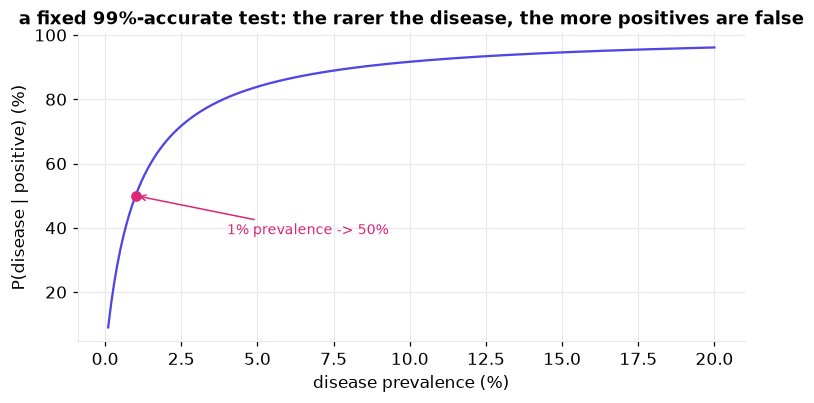

In [5]:
N = 10_000
prevalence = 0.01        # 1% have the disease
sensitivity = 0.99       # P(+ | disease)
specificity = 0.99       # P(- | healthy); false-positive rate = 1%

sick    = N * prevalence            # 100
healthy = N * (1-prevalence)        # 9,900
TP = sick * sensitivity             # 99 true positives
FP = healthy * (1-specificity)      # 99 false positives
p_disease_given_pos = TP / (TP + FP)
print(f"of {N:,} people: {sick:.0f} sick, {healthy:.0f} healthy")
print(f"true positives  = {sick:.0f} x 0.99 = {TP:.0f}")
print(f"false positives = {healthy:.0f} x 0.01 = {FP:.0f}")
print(f"\nP(disease | positive) = {TP:.0f} / ({TP:.0f} + {FP:.0f}) = {p_disease_given_pos:.2f}  <- only 50%!")

# how it depends on the base rate
prev = np.linspace(0.001, 0.2, 200)
ppv = (prev*sensitivity) / (prev*sensitivity + (1-prev)*(1-specificity))
fig, ax = plt.subplots(figsize=(7,3.8))
ax.plot(prev*100, ppv*100, color=INDIGO)
ax.scatter([1],[50], color=PINK, zorder=5); ax.annotate("1% prevalence -> 50%", (1,50), (4,38), color=PINK, fontsize=9,
           arrowprops=dict(arrowstyle="->", color=PINK))
ax.set_xlabel("disease prevalence (%)"); ax.set_ylabel("P(disease | positive) (%)")
ax.set_title("a fixed 99%-accurate test: the rarer the disease, the more positives are false")
plt.tight_layout(); plt.show()

**Base rates dominate rare events.** With 1% prevalence, the 99 true positives are exactly matched by 99 false positives drawn from the huge healthy majority, so a positive test means just a 50% chance of disease. This is the **base-rate fallacy**: a 1978 study found most Harvard physicians estimated the answer near 95%, neglecting the prevalence. The cure is to count natural frequencies, true positives against false positives, which the next chapter formalizes as Bayes' theorem.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 5 · CONDITIONAL PROBABILITY IN ML</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">A classifier estimates P(class | features)</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Conditional probability is the literal job of a classifier. A spam filter estimates P(spam | the words it sees). Here is the simplest version from counts.</div>
</div>

In [6]:
# 1000 emails, of which 300 are spam. Does the word "free" appear?
#                free   no-free   total
#   spam          180      120      300
#   ham            70      630      700
p_spam = 300/1000
p_free_given_spam = 180/300
p_free = (180+70)/1000
p_spam_given_free = (180) / (180+70)        # of the 250 emails with "free", how many are spam?
print(f"P(spam)            = {p_spam:.2f}")
print(f"P(free | spam)     = {p_free_given_spam:.2f}")
print(f"P(spam | free)     = 180/250 = {p_spam_given_free:.2f}   <- seeing \"free\" raises spam odds from 0.30 to 0.72")
print("\nNaive Bayes does exactly this, then combines many words by ASSUMING they are")
print("conditionally independent given the class, the \"naive\" part.")

P(spam)            = 0.30
P(free | spam)     = 0.60
P(spam | free)     = 180/250 = 0.72   <- seeing "free" raises spam odds from 0.30 to 0.72

Naive Bayes does exactly this, then combines many words by ASSUMING they are
conditionally independent given the class, the "naive" part.


**Classification is conditional probability.** The filter wants P(spam | features); from the counts, a single word "free" lifts the spam probability from 0.30 to 0.72. Real classifiers combine many such conditional probabilities. Naive Bayes does so by assuming the features are independent given the class, a strong, often-wrong assumption that nonetheless works remarkably well, which is the bridge from this chapter into machine learning.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎯 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:8px">
<li><b>Conditional probability:</b> P(A | B) = P(A and B) / P(B), restrict the world to B.</li>
<li><b>Multiplication rule:</b> P(A and B) = P(B) x P(A | B); trees multiply along conditional branches.</li>
<li><b>Independence:</b> P(A | B) = P(A), the condition changes nothing.</li>
<li><b>Base-rate trap:</b> a very accurate test for a rare disease still yields many false positives.</li>
<li><b>In ML:</b> classifiers estimate P(class | features); naive Bayes assumes conditional independence.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>